# Week 9 - PCA and SVD: Projection and Reconstruction

**Mode:** experiment  
**Companion theory:** [`notes/w09_mml_linear_algebra.md`](../notes/w09_mml_linear_algebra.md)  
**Companion exercises:** [`proofs/w09_mml_linear_algebra.md`](../proofs/w09_mml_linear_algebra.md)  
**Workflow:** keep this notebook as the TODO baseline and do your work in the `_solved` copy.

## Goal

Use PCA to compress an elongated synthetic dataset from two dimensions to one, reconstruct it, and connect the result to eigendecomposition, SVD, and low-rank approximation.

## Success criteria

1. The leading covariance eigenvector and leading right-singular vector agree up to sign.
2. A one-component reconstruction follows the dataset's dominant direction.
3. Reconstruction MSE with two components is no larger than with one component and is numerically near zero.
4. Your interpretation distinguishes PCA's linear compression from the nonlinear representations used in diffusion models.


## Reading map for when you get stuck

Read only the smallest relevant section before returning to the TODO:

- **What problem is PCA solving?** MML §10.1, printed pp. 318-319 ([local PDF, page 324](../sources/mml/pdfs/mml-book.pdf#page=324)).
- **Why maximize variance?** MML §10.2, printed pp. 320-324 ([local PDF, page 326](../sources/mml/pdfs/mml-book.pdf#page=326)).
- **Why is PCA a projection/reconstruction problem?** MML §10.3, printed pp. 325-332 ([local PDF, page 331](../sources/mml/pdfs/mml-book.pdf#page=331)).
- **How do eigenvectors and low-rank approximation enter?** MML §10.4, printed pp. 333-335 ([local PDF, page 339](../sources/mml/pdfs/mml-book.pdf#page=339)).
- **Your own foundations:** the `Connection to PCA`, `Singular Value Decomposition`, and `Matrix Approximation` sections of the [Week 9 note](../notes/w09_mml_linear_algebra.md).
- **Small SVD worked by hand:** [MML Exercise 4.9 in your proof file](../proofs/w09_mml_linear_algebra.md#curriculum-exercise---exercise-49).

The [MML source catalog](../sources/mml/) records the official source and local-copy policy.


---

## Setup and synthetic data

The dataset is deliberately elongated: one latent direction has much larger variance than the other. We rotate it and shift it away from the origin so that centering is visibly necessary.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

config = {
    "seed": 9,
    "n_samples": 400,
    "major_std": 3.0,
    "minor_std": 0.55,
    "angle_degrees": 32.0,
    "offset": np.array([2.5, -1.0]),
}

rng = np.random.default_rng(config["seed"])
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
config


{'seed': 9,
 'n_samples': 400,
 'major_std': 3.0,
 'minor_std': 0.55,
 'angle_degrees': 32.0,
 'offset': array([ 2.5, -1. ])}

In [2]:
angle = np.deg2rad(config["angle_degrees"])
rotation = np.array(
    [
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)],
    ]
)

latent = rng.normal(size=(config["n_samples"], 2))
latent *= np.array([config["major_std"], config["minor_std"]])
X = latent @ rotation.T + config["offset"]

assert X.shape == (config["n_samples"], 2)
assert np.allclose(rotation.T @ rotation, np.eye(2))
print(f"Dataset shape: {X.shape}")


Dataset shape: (400, 2)


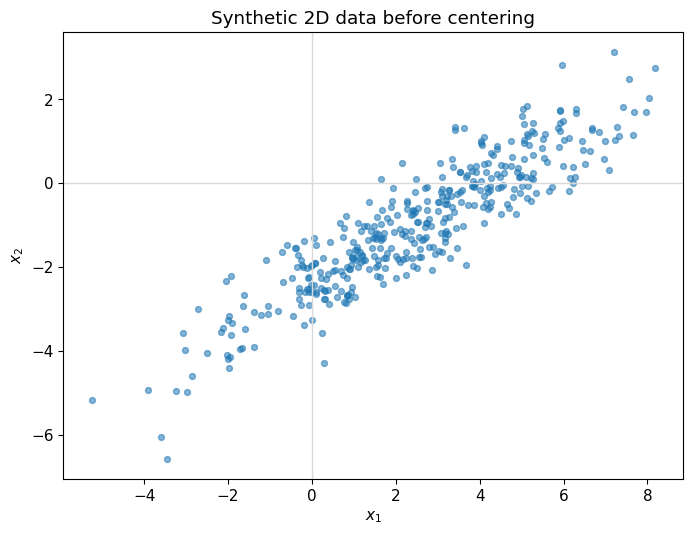

In [3]:
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.55)
ax.axhline(0, color="0.85", linewidth=1)
ax.axvline(0, color="0.85", linewidth=1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Synthetic 2D data before centering")
plt.show()


---

## Part 1 - Center the data

PCA describes variation around the empirical mean. If the data are not centered, the origin affects the directions we recover.


In [4]:
mean = X.mean(axis=0)
X_centered = X - mean

assert mean.shape == (2,)
assert np.allclose(X_centered.mean(axis=0), np.zeros(2), atol=1e-12)
print("Empirical mean:", mean)
print("Centered mean:", X_centered.mean(axis=0))


Empirical mean: [ 2.45331843 -1.00872371]
Centered mean: [-1.27342581e-15  4.69624339e-16]


### Checkpoint 1

Before continuing, explain in one or two sentences why subtracting the same mean from every observation is a translation rather than a rotation or scaling.

**Your explanation:** Centering subtracts the same mean vector from every observation, so it translates the entire dataset until its empirical mean is at the origin. It preserves the relative positions, distances, directions, and scale of the observations because the same displacement is applied to every point.


---

## Part 2 - PCA from the covariance eigendecomposition

For a centered data matrix $X_c\in\mathbb{R}^{n\times d}$, use MML's data-covariance convention

$$
S=\frac{1}{n}X_c^\top X_c.
$$

MML stores observations as columns; this notebook uses the common code convention of observations as rows, which is why the product is $X_c^\top X_c$. Because $S$ is real and symmetric, `np.linalg.eigh` returns real eigenvalues and orthonormal eigenvectors. NumPy returns them in ascending order, while PCA conventionally orders components by decreasing variance.

**Stuck?** Return to MML §10.2 and your note's eigendecomposition section.


In [5]:
# TODO 1: compute the covariance, its eigendecomposition, and reorder both
# eigenvalues and eigenvectors from largest to smallest eigenvalue.
covariance = X_centered.T@X_centered/X_centered.shape[0]
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
eigenvalues = eigenvalues[::-1]
principal_directions = eigenvectors[:, ::-1]

# CHECKPOINTS: uncomment after completing the TODO.
assert np.allclose(covariance, covariance.T)
assert np.all(np.diff(eigenvalues) <= 0)
assert np.allclose(principal_directions.T @ principal_directions, np.eye(2))
print("Explained variances:", eigenvalues)
print("Principal directions (columns):\n", principal_directions)


Explained variances: [8.1944179 0.3143157]
Principal directions (columns):
 [[-0.86025671  0.50986115]
 [-0.50986115 -0.86025671]]


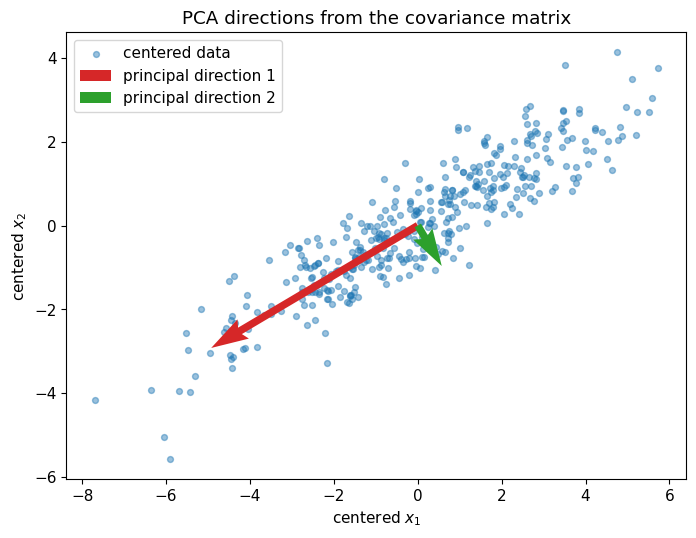

In [6]:
def plot_principal_directions(X, origin, directions, variances):
    """Plot centered observations and variance-scaled direction vectors."""
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.45, label="centered data")

    colors = ["tab:red", "tab:green"]
    for index, (direction, variance, color) in enumerate(
        zip(directions.T, variances, colors), start=1
    ):
        scale = 2 * np.sqrt(variance)
        ax.quiver(
            *origin,
            *(scale * direction),
            angles="xy",
            scale_units="xy",
            scale=1,
            color=color,
            width=0.012,
            label=f"principal direction {index}",
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"centered $x_1$")
    ax.set_ylabel(r"centered $x_2$")
    ax.set_title("PCA directions from the covariance matrix")
    ax.legend()
    plt.show()


if np.isfinite(principal_directions).all() and np.isfinite(eigenvalues).all():
    plot_principal_directions(
        X_centered, np.zeros(2), principal_directions, eigenvalues
    )
else:
    print("Complete TODO 1 to plot the principal directions.")


### Checkpoint 2

1. Which direction has the larger eigenvalue?
2. What does that eigenvalue measure in this dataset?
3. Why are the two covariance eigenvectors orthogonal here?

**Your answers:** 
1. The first principal direction, shown in red, has the larger eigenvalue. It corresponds to eigenvalues[0] after reordering.
2. Each eigenvalue measures the variance of the centered data along its corresponding principal direction. Therefore, the larger first eigenvalue means that the data are more spread out along the first principal direction.
3. This orthogonality follows from the symmetry of the covariance matrix. By the spectral theorem, a real symmetric matrix has an orthonormal basis of eigenvectors, and np.linalg.eigh returns the eigenvectors in this orthonormal form.


---

## Part 3 - Recover the same directions with SVD

Apply SVD directly to the centered data matrix:

$$
X_c=U\Sigma V^\top.
$$

The columns of $V$ are directions in feature space. Since

$$
S=\frac{1}{n}X_c^\top X_c
=V\frac{\Sigma^2}{n}V^\top,
$$

the covariance eigenvalues should equal $\sigma_i^2/n$. Eigenvectors and singular vectors may differ by a sign without representing different directions.

**Stuck?** Review MML §10.4, your SVD note, and Exercise 4.9.


In [7]:
# TODO 2: compute the compact SVD of X_centered.
U, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
svd_directions = Vt.T
# TODO 2: compare SVD directions and variances with the covariance result.
direction_agreement = np.abs(principal_directions.T @ svd_directions)
variances_from_svd = np.square(singular_values) / X_centered.shape[0]

# CHECKPOINTS: uncomment after completing TODO 1 and TODO 2.
assert np.allclose(X_centered, (U * singular_values) @ Vt)
assert np.allclose(variances_from_svd, eigenvalues)
assert np.allclose(direction_agreement, np.eye(2), atol=1e-10)
print("Absolute direction agreement:\n", direction_agreement)


Absolute direction agreement:
 [[1.00000000e+00 1.87664629e-16]
 [1.87588423e-16 1.00000000e+00]]


### Checkpoint 3

Explain why comparing vectors with `np.allclose(v_eig, v_svd)` can fail even when both methods recovered the same geometric direction.

**Your explanation:** Eigenvectors and singular vectors are defined only up to sign: if \(v\) is a valid direction, then \(-v\) is equally valid and spans the same one-dimensional subspace. Consequently, two algorithms can return opposite normalized representatives of the same geometric line, causing np.allclose(v_eig, v_svd) to fail even though the directions agree.


---

## Part 4 - Project from 2D to 1D

Let $W_k\in\mathbb{R}^{2\times k}$ contain the first $k$ principal directions. For row-wise observations, the compressed coordinates are

$$
Z_k=X_cW_k.
$$

$Z_1\in\mathbb{R}^{n\times1}$ is the one-dimensional representation.

**Stuck?** MML §10.3.2 develops the coordinates of the projected observations.


In [8]:
def project_to_components(X_centered, directions, k):
    """Project centered rows onto the first k principal directions."""
    # TODO 3: select W_k and compute the compressed coordinates.
    W_k = directions[:, :k]
    coordinates = X_centered @ W_k
    return coordinates


Z_1 = project_to_components(X_centered, principal_directions, k=1)
Z_2 = project_to_components(X_centered, principal_directions, k=2)

# CHECKPOINTS: uncomment after completing TODO 3.
assert Z_1.shape == (config["n_samples"], 1)
assert Z_2.shape == (config["n_samples"], 2)
print("First five 1D coordinates:\n", Z_1[:5])


First five 1D coordinates:
 [[ 2.36637694]
 [ 4.93153324]
 [-3.47986434]
 [-1.33246669]
 [ 1.12698699]]


### Thursday stop point

Part 1 is complete when the centered data, covariance directions, SVD comparison, and $Z_1$ projection work and their assertions pass. Stop here after 60-75 minutes; reconstruction belongs to Friday.


---

## Part 5 - Reconstruct in 2D and measure the error

Map the compressed coordinates back to the original coordinate system:

$$
\widehat X_k=Z_kW_k^\top+\bar x.
$$

**Stuck?** MML §10.3.1 defines the reconstruction objective; §10.4 connects it to low-rank approximation.


In [12]:
def reconstruct_from_components(coordinates, mean, directions, k):
    """Map k-dimensional PCA coordinates back to the original 2D space."""
    # TODO 4: select the same W_k and reconstruct in the original coordinates.
    W_k = directions[:, :k]
    reconstruction = coordinates @ W_k.T + mean
    return reconstruction


def reconstruction_mse(X, reconstruction):
    """Return average squared Euclidean reconstruction error per observation."""
    return float(np.mean(np.sum((X - reconstruction) ** 2, axis=1)))


X_reconstructed_1 = reconstruct_from_components(
    Z_1, mean, principal_directions, k=1
)
X_reconstructed_2 = reconstruct_from_components(
    Z_2, mean, principal_directions, k=2
)

mse_by_components = {
    1: reconstruction_mse(X, X_reconstructed_1),
    2: reconstruction_mse(X, X_reconstructed_2),
}
print(f"mse_by_components: {mse_by_components}")

# CHECKPOINTS: uncomment after completing TODO 4.
assert mse_by_components[2] <= mse_by_components[1]
assert np.isclose(mse_by_components[1], eigenvalues[1])
assert np.isclose(mse_by_components[2], 0.0, atol=1e-20)


mse_by_components: {1: 0.31431569667679826, 2: 3.158525108795067e-31}


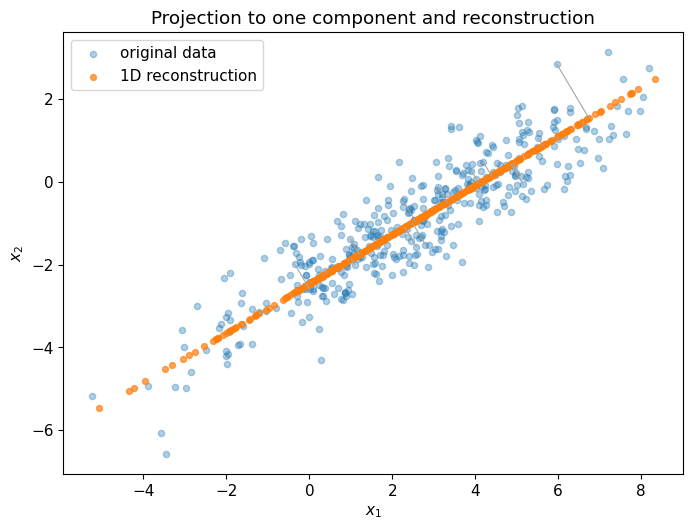

In [13]:
if np.isfinite(X_reconstructed_1).all():
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1], s=20, alpha=0.35, label="original data")
    ax.scatter(
        X_reconstructed_1[:, 0],
        X_reconstructed_1[:, 1],
        s=18,
        alpha=0.7,
        label="1D reconstruction",
    )

    for index in range(0, len(X), 20):
        ax.plot(
            [X[index, 0], X_reconstructed_1[index, 0]],
            [X[index, 1], X_reconstructed_1[index, 1]],
            color="0.65",
            linewidth=0.8,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_title("Projection to one component and reconstruction")
    ax.legend()
    plt.show()
else:
    print("Complete TODO 1, TODO 3, and TODO 4 to plot the reconstruction.")


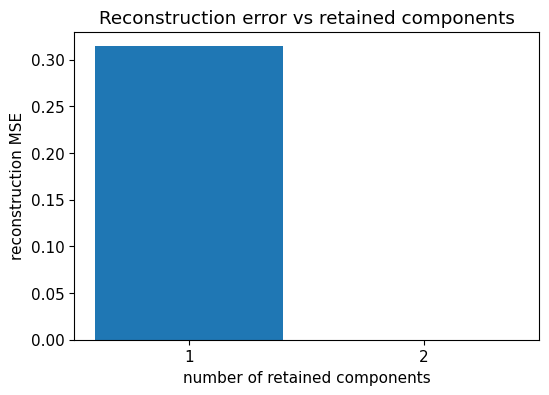

In [14]:
if all(np.isfinite(value) for value in mse_by_components.values()):
    fig, ax = plt.subplots(figsize=(6, 4))
    components = list(mse_by_components)
    errors = [mse_by_components[k] for k in components]
    ax.bar(components, errors, color=["tab:blue", "tab:green"])
    ax.set_xticks(components)
    ax.set_xlabel("number of retained components")
    ax.set_ylabel("reconstruction MSE")
    ax.set_title("Reconstruction error vs retained components")
    plt.show()
else:
    print("Complete TODO 4 to compare reconstruction errors.")


### Checkpoint 4 - Interpret the experiment

Answer in your own words:

1. Why does the one-component reconstruction lie on a line?
2. What information was discarded, and how is that visible in the plot?
3. Why is the two-component reconstruction nearly exact?
4. How is the one-component MSE related to the discarded covariance eigenvalue?

**Your interpretation:** 

1. A one-component reconstruction preserves only each observation’s coordinate along the first principal direction. Therefore, after adding the mean back, every reconstructed point lies on the line through the mean spanned by that principal direction.

2. The variation along the second principal direction was discarded. In the plot, the reconstructed points lie entirely on the first principal-component line, while the gray segments show the residual variation removed from selected original points.

3. Because the original data is two-dimensional, the two principal directions form an orthonormal basis for the entire feature space. Retaining both components therefore preserves all the information, apart from negligible floating-point error.

4. In this example, the one-component MSE is approximately $0.314$, which equals the eigenvalue associated with the discarded second principal direction. More generally, with this definition of MSE and covariance, PCA’s reconstruction MSE equals the sum of the covariance eigenvalues corresponding to all discarded principal directions:

$$
\operatorname{MSE}_k=\sum_{j=k+1}^{d}\lambda_j.
$$


---

## Part 6 - Diffusion contact

Use the experiment as evidence for `notes/w09_linear_algebra_in_unets.md`. Keep that note to about one page and address these prompts:

1. **Linear maps:** where do fixed-weight linear transformations appear in convolutions and learned feature projections?
2. **Low-dimensional representations:** how is PCA's 2D-to-1D encoding similar to, and more limited than, a learned encoder used before latent diffusion?
3. **Low-rank intuition:** what does retaining dominant directions preserve, and what can truncation discard?
4. **Important limitation:** why should we not call an entire U-Net, attention block, or residual block linear merely because it contains linear operations?

Optional bridge for prompt 2: MML §10.7 presents PCA from a latent-variable perspective. Save a full reading of that section for Week 11 unless you need it now.

### Final findings

- **Main numerical result:** The leading component retained approximately $96.3\%$ of the total variance. The one-component reconstruction MSE was $0.3143$, equal to the discarded second covariance eigenvalue, while the two-component MSE was approximately $3.16\times10^{-31}$ and therefore zero up to floating-point error.
- **Evidence from the reconstruction plot:** Every one-component reconstruction lies on the line through the empirical mean in the leading principal direction. The gray residual segments show the variation orthogonal to that line that PCA discarded.
- **Relationship between eigendecomposition and SVD:** The covariance eigenvectors agreed with the right singular vectors of the centered data matrix up to sign, and their values satisfied $\lambda_i=\sigma_i^2/n$. Both methods therefore recovered the same principal subspaces.
- **Main limitation of this PCA experiment:** It uses simple two-dimensional synthetic data and searches only for one global linear subspace that minimizes squared reconstruction error. It does not represent nonlinear image structure, learned semantics, or the dynamics of a diffusion process.
- **Diffusion connection worth remembering:** A latent diffusion model also encodes data into a smaller representation and later decodes it, but its learned nonlinear encoder-decoder can represent much richer structure than PCA. Linear maps and low-rank ideas remain useful building blocks, but they do not make the complete diffusion architecture linear.


---

## Done criteria

Week 9 S3 is complete when all TODOs and checkpoint explanations are filled, both plots render, the assertions pass, and `notes/w09_linear_algebra_in_unets.md` contains the short diffusion connection. Optional Exercise 4.10 and MML §10.7 should not delay closure.
